In [1]:
import pandas as pd

In [2]:
import sys
import os
# Get the parent directory
parent_folder = os.path.dirname(os.getcwd())
# add the parent directory to the Python path so that the scripts can be imported
sys.path.append(parent_folder)

In [3]:
from modules.point_reg_aus import point_regressor
from modules.utils import read_column_list_from_config

# Load data

In [4]:
# Load the data
fname_aus = '../data/ausgrid/ausgrid_merged_preprocessed_part1.csv'
df_aus = pd.read_csv(fname_aus)

In [5]:
df_aus['total_net']

0        19292.0
1        18298.0
2        18872.0
3        14436.0
4        15894.0
          ...   
17515    38028.0
17516    40488.0
17517    34240.0
17518    27956.0
17519    23402.0
Name: total_net, Length: 17520, dtype: float64

In [6]:
# list_of_features = read_column_list_from_config(
#     '../config/feature_columns_norm.txt')
list_of_features = ['air_temp_norm',
                    'precipitation_rate_norm',
                    'wind_speed_10m_norm',
                    'cloud_opacity',
                    'ghi_norm',
                    'total_net_norm',
                    'azimuth_norm',
                    'zenith_norm',
                    'cos_HoD_norm',
                    'sin_HoD_norm']
list_of_features_selected = ['ghi_norm',
                             'air_temp_norm',
                             'total_net_norm',
                             'azimuth_norm']
my_seed = 42

In [7]:
point_reg = point_regressor(original_data=df_aus, list_of_features=list_of_features,
                            random_seed=my_seed, ghi_threshold=0.01)

X_train.shape: (8954, 10), X_test.shape: (1259, 10), X_prop_train.shape: (7695, 10), X_cal.shape: (1259, 10)


# Feature Selection

## Tree-based Feature Selection



### Based on MDI
Feature importances are provided by the fitted attribute feature_importances_ and they are computed as the mean and standard deviation of accumulation of the impurity decrease within each tree. \
https://scikit-learn.org/stable/auto_examples/ensemble/plot_forest_importances.html#feature-importance-based-on-mean-decrease-in-impurity

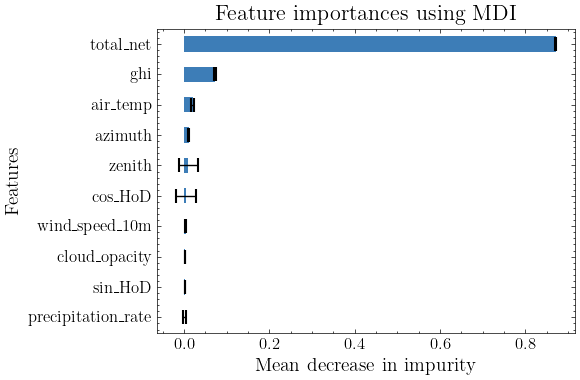

In [8]:
point_reg.tree_based_selection_MDI()

### Based on Permutation
Permutation feature importance overcomes limitations of the impurity-based feature importance: they do not have a bias toward high-cardinality features and can be computed on a left-out test set. \
https://scikit-learn.org/stable/modules/permutation_importance.html#permutation-feature-importance
\
High-cardinality categorical features are those that have a large number of unique values, such as product IDs, zip codes, or names.

/home/jhe/prjs/envs_py/prob-trans/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/home/jhe/prjs/envs_py/prob-trans/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/home/jhe/prjs/envs_py/prob-trans/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/home/jhe/prjs/envs_py/prob-trans/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/home/jhe/prjs/envs_py/prob-trans/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not

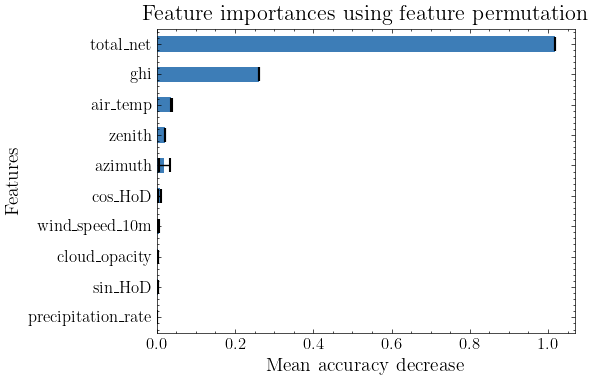

In [9]:
point_reg.tree_based_selection_permutation()

# Comparison between regressors

In [10]:
point_reg.selected_features = list_of_features_selected

Using selected features: ['ghi_norm', 'air_temp_norm', 'total_net_norm', 'azimuth_norm']
Evaluating on test set (n=1259 samples).
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000237 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 784
[LightGBM] [Info] Number of data points in the train set: 7695, number of used features: 4
[LightGBM] [Info] Start training from score 0.383953
              R2  Adjusted R2      RMSE  Training time (s)
mlr     0.868372     0.867952  0.092687           0.001296
rfr     0.948197     0.948032  0.058146           0.281881
lgb     0.948163     0.947997  0.058166           0.059618
fcnn    0.954971     0.954827  0.054211          15.610726
resnet  0.953141     0.952991  0.055302          27.187176
lstm    0.951173     0.951017  0.056452          25.948927


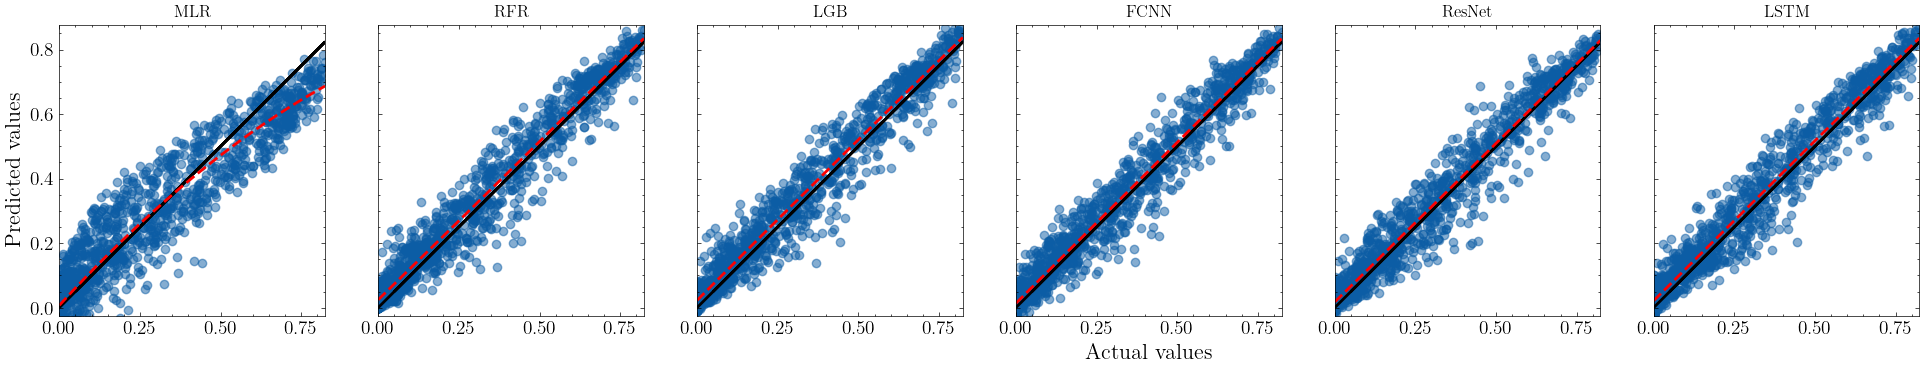

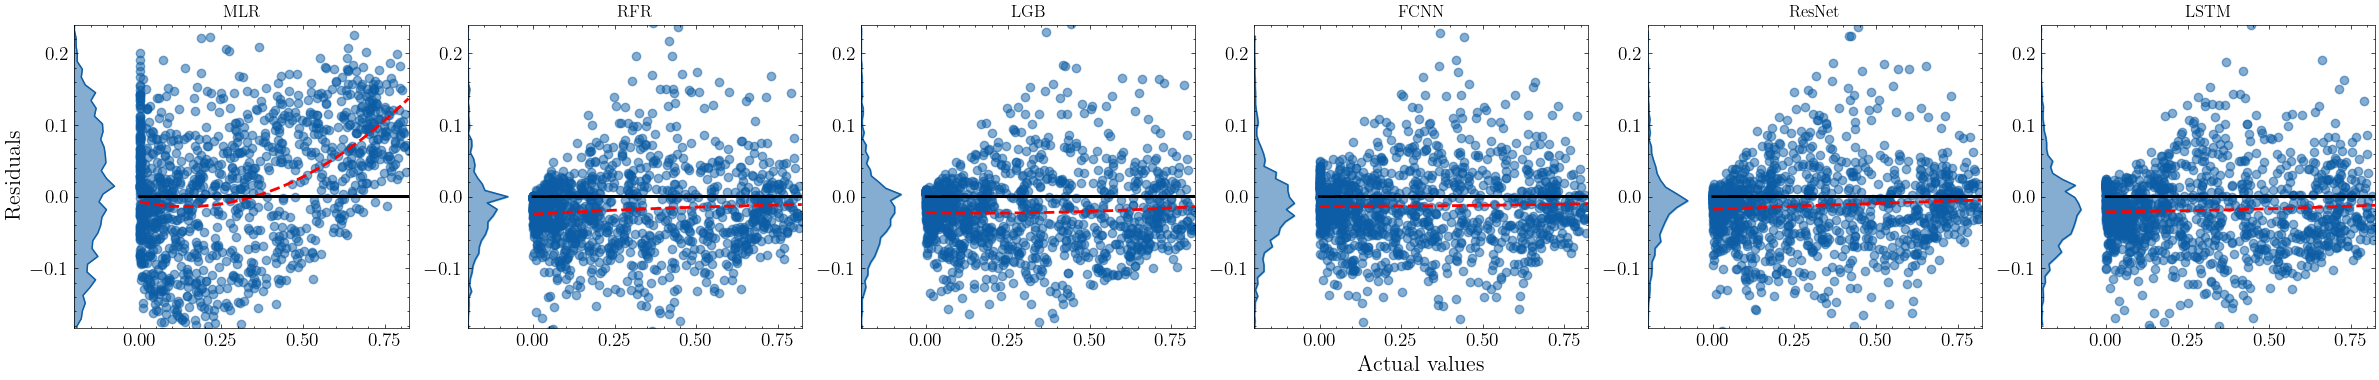

In [11]:
point_reg.compare_regressors(
    fname1="regressor_comparison1_ausgrid.pdf", fname2="regressor_comparison2_ausgrid.pdf")